# Lab11: Prepocesamiento de Datos para Machine Learning
 Objetivo: Aplicar las Principales tecnicas de prepocesamiento de datos para preparar un DataSet antes de entrenar un modelo de ML.
 
 Problema: Se desea construir un modelo capaz de predecir si un pasajero sebrevivio o no al hundimiento del Titanic.

In [1]:
# Importamos librerias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
pip install scikit-learn

In [2]:
import kagglehub

C:\Users\juang\miniconda3\envs\Extraccion9BEscolarizado\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
pip install kagglehub

In [3]:
path = kagglehub.dataset_download("yasserh/titanic-dataset")

100%|██████████| 22.0k/22.0k [00:00<00:00, 194kB/s]

Extracting files...


In [4]:
print("Ruta del dataset: ", path)

Ruta del dataset:  C:\Users\juang\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [5]:
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv")

In [7]:
dfTitanic.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

# Parte 1. Comprension del problema
 Determinar si sobreviven al hundimiento del titanic, con base en la informacion obtenida

 Survived

 0 - No sobrevivio

 1 - Sobrevivio

In [8]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

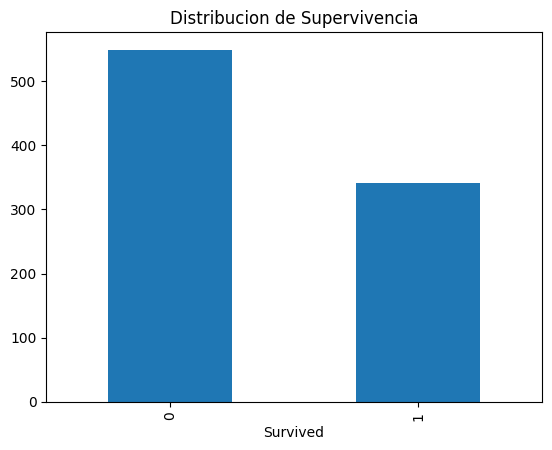

In [9]:
dfTitanic["Survived"].value_counts().plot(
    kind="bar"
)
plt.title("Distribucion de Supervivencia")
plt.show()

# Parte 2. Exploracion inicial

In [14]:
dfTitanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
# Hipotesis inicial
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [16]:
dfTitanic.groupby(
    "Pclass"
)["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [17]:
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## Parte 3: Correccion e hipotesis

Creamos una matris de correlacion para identificar la relacion lineal entre las variables, NO identifica la importancia real de variables en el modelo

In [18]:
variables_numericas = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

In [19]:
corr = dfTitanic[variables_numericas].corr()

In [20]:
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


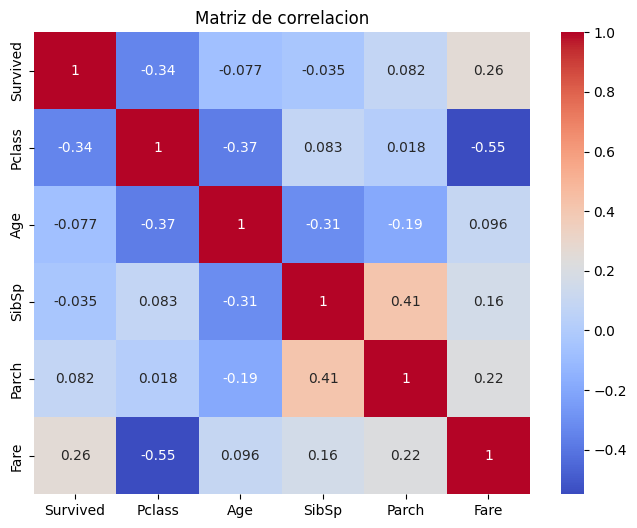

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlacion")
plt.show()

# Parte 4. Seleccion de variables y Variable objetivo

x - Variables que utilizara el modelo

y - Variable que queremos predecir

In [23]:
columnas = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

In [24]:
# Definimos x y
x = dfTitanic[columnas]
y = dfTitanic["Survived"]

In [25]:
print(y.name)

Survived


# Parte 5. Tratamiento de los valores

Para simplicar el proceso realizaremos la imputacion de los datos antes de la separacion TRAIN/TEST

In [26]:
# Revisamos las varianles predictorias 
x.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [28]:
x["Age"] = x["Age"].fillna(
    x["Age"].median()
)

C:\Users\juang\AppData\Local\Temp\ipykernel_9296\1295983609.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Age"] = x["Age"].fillna(


In [29]:
x["Embarked"] = x["Embarked"].fillna(
    x["Embarked"].mode()[0]
)

C:\Users\juang\AppData\Local\Temp\ipykernel_9296\1058067266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Embarked"] = x["Embarked"].fillna(


In [30]:
x.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [31]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


# Parte 6. Escalado de datos

Los algoritmos no entienden texto. Se deben convertir las variables categoriocas en variables numericas

In [32]:
x = pd.get_dummies(
    x,
    columns=["Sex","Embarked"],
    drop_first=True
)

In [33]:
x.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


# Parte 7. Particionamos los datos
No debemos entrenar y evaluar utilizando los mismos datos

la recomendacion es:

Entrenamiento: 80% Pruebas: 20%

In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.20,
    random_state=42
)

In [35]:
print ("Prueba: ", y_test.shape)

Prueba:  (179,)


In [36]:
variables_numericas

['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [38]:
print ("Prueba: ", y_test.shape)

Prueba:  (179,)


# Parte 8. Estado de las variables

Las variables numericas tienen valores distintos. El escalado evita que una variable domine mas que otra.

In [39]:
columnas_numericas = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

In [40]:
x_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,712.000000,712.000000,712.000000,712.000000
mean,29.204129,32.586276,0.553371,0.379213
std,13.007971,51.969529,1.176404,0.791669
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,7.925000,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,30.500000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


scaler = StandardScaler()
x_train[columnas_numericas] = scaler.fit_transform(
    x_train[columnas_numericas]
)
x_train[columnas_numericas] = scaler.transform(
    x_train[columnas_numericas]
)

In [41]:
x_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,712.000000,712.000000,712.000000,712.000000
mean,29.204129,32.586276,0.553371,0.379213
std,13.007971,51.969529,1.176404,0.791669
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,7.925000,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,30.500000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


# Parte 9. Entrenamiento de los datos

Usaremos un arbol de decision para clasificar registros

In [42]:
modelo = DecisionTreeClassifier (
    max_depth = 4,
    random_state=42
)

In [43]:
modelo.fit(
    x_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

# Parte 10. Evaluamos el modelo

Realizamos predicciones para evaluar el modelo

In [45]:
predicciones = modelo.predict(
    x_test
)

In [46]:
pd.DataFrame({
    "Real ": y_test,
    "Prediccion ": predicciones
}).head()

,Real,Prediccion
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1


# Parte 11. Evaluacion del modelo

El accuracy determinar el porcentajede predicciones correctas por el modelo

In [47]:
accuracy = accuracy_score(
    y_test,
    predicciones
)

In [49]:
print ( f"Accuracy :{accuracy: 4f}")

Accuracy : 0.798883


 
 |Accuracy| Interpretacion|
 -------------------------
 

# Parte 12. Importancia de las variables
Analizar las variables mas relevantes para el algoritmo al realizar las predicciones

In [53]:
importancias = pd.DataFrame({
    "Variable" : x_train.columns,
    "Importancia" : modelo.feature_importances_ # Que variable es importante para el modelo
})

In [54]:
importancias.sort_values(
    by="Importancia",
    ascending=False
)

,Variable,Importancia
5,Sex_male,0.579608
0,Pclass,0.200498
4,Fare,0.081064
1,Age,0.078872
2,SibSp,0.046059
7,Embarked_S,0.013900
3,Parch,0.000000
6,Embarked_Q,0.000000
